In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "Time New Roman",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

from vs_ns_periodic_mrSAV_solver import vs_mrSAV_Vorticity_Stream_Periodic_Solver as vs_mrSAV_solver

In [2]:
# ─── Common setup ────────────────────────────────────────────────────────────
delta = 0.05   # perturbation amplitude
gam   = 1000   # mean-reversion parameter γ
T     = 1.2    # final time
s_domain = (0, 0, 1, 1)   # Ω = (0,1)×(0,1)

def no_force(X, Y, t):
    return np.zeros_like(X)

def make_initial_vorticity(rho: float, N: int) -> np.ndarray:
    """
    Returns initial vorticity ω₀ on the (N,N) interior grid
    via spectral differentiation of the double-shear-layer velocity field.
    """
    tmp = vs_mrSAV_solver(1.0, 1.0, s_domain, [N, N],
                          np.zeros((N + 1, N + 1)), no_force, "ETD_mrGSAV_MS2_b")
    x, y = tmp.X[:-1, :-1], tmp.Y[:-1, :-1]

    u = np.where(y <= 0.5, np.tanh(rho * (y - 0.25)), np.tanh(rho * (0.75 - y)))
    v = delta * np.sin(2 * np.pi * x)

    return tmp.velocity2vorticity(u, v)   # shape (N, N)


In [3]:
# ρ = 100, ν = 5×10⁻⁵, 256×256 modes
# δt = 6×10⁻⁴  (intentionally > paper's 3×10⁻⁴ to stress-test ETDMS2 stability)
rho_thin = 100
nu_thin  = 5e-5
N_thin   = 256
dt_thin  = 6e-4

omega0_thin     = make_initial_vorticity(rho_thin, N_thin)
omega0_thin_pad = np.pad(omega0_thin, ((0, 1), (0, 1)))

# ETD_mrGSAV_MS2_b — expected to reach T = 1.2 without blow-up
solver_thin_ref = vs_mrSAV_solver(nu_thin, gam, s_domain, [N_thin, N_thin], omega0_thin_pad, no_force, "ETD_mrGSAV_MS2_b")
solver_thin_ref.solve_fix_step((0, T), dt_thin/2, snapshot=[0.4, 0.8, T])
omega_thin_T_ref = solver_thin_ref.Omega

solver_thin = vs_mrSAV_solver(nu_thin, gam, s_domain, [N_thin, N_thin], omega0_thin_pad, no_force, "ETD_mrGSAV_MS2_b")
solver_thin.solve_fix_step((0, T), 5*dt_thin/6, snapshot=[T])
omega_thin_T = solver_thin.Omega[0]

# ETDMS2 — blows up before T=1.2 at this step size.
# snapshot=[0.8, T]: Omega[0] captures the last valid state at t=0.8 (before blow-up at ~0.83);
#                    Enstrophy[] is always recorded and reveals when divergence begins.
solver_thin_etdms2 = vs_mrSAV_solver(nu_thin, gam, s_domain, [N_thin, N_thin], omega0_thin_pad, no_force, "ETDMS2")
solver_thin_etdms2.solve_fix_step((0, T), dt_thin, snapshot=[0.8, T])
omega_thin_pre_blowup_etdms2 = solver_thin_etdms2.Omega[0]   # t=0.8 (valid)

# Detect blow-up time
_valid = np.isfinite(solver_thin_etdms2.Enstrophy)
t_blowup_thin = solver_thin_etdms2.tn[np.argmax(~_valid)] if not _valid.all() else None
print(f"ETDMS2 thin-layer blow-up time: {t_blowup_thin:.4f}" if t_blowup_thin else "ETDMS2: no blow-up detected")

# mr_SAV_BDF2 — expected to be stable (implicit BDF2, reference comparison)
solver_thin_mrsav_bdf = vs_mrSAV_solver(nu_thin, gam, s_domain, [N_thin, N_thin], omega0_thin_pad, no_force, "mr_SAV_BDF2")
solver_thin_mrsav_bdf.solve_fix_step((0, T), dt_thin, snapshot=[T])
omega_thin_T_mrsav_bdf = solver_thin_mrsav_bdf.Omega[0]


 1.200000\1.2, Elapse: 0.023 s, Vorticity Energy:0.4694, Enstrophy:57.8548, Palinstrophy:391598.2224, Maximum:77.63, |q-1|:6.0759e-03        
 1.200000\1.2, Elapse: 0.022 s, Vorticity Energy:0.4694, Enstrophy:58.0997, Palinstrophy:490862.3902, Maximum:77.73, |q-1|:2.0902e-01        
 0.832800\1.2, Elapse: 0.022 s, Vorticity Energy:nan, Enstrophy:nan, Palinstrophy:nan, Maximum:nan, |q-1|:0.0000e+00     78519013388211114825716769592896525234614089517919486126126431743658679744673888902367909196225722508337171971927614454341139847457131093563124280880164430415710161833943034987806720.00, |q-1|:0.0000e+00     4243583404170100916873129479304452729688541291689175358313020767410541417488299681988382172147766990793438275979059119720221759516565891049601368064.0000, Palinstrophy:660928744826031853723756196815058879563106966910630386392740993734168657794679442136593947087310121299528134923586206566153413415850111976219917067621349794042371348144035570721094522864309737038961276535133175808.0000,

/Users/wanghaifeng/Desktop/ETD-mr-SAV-MS2/vs_ns_periodic_mrSAV_solver.py:154: RuntimeWarning: overflow encountered in multiply
  return self.h*np.sum(f*g)
/Users/wanghaifeng/Desktop/ETD-mr-SAV-MS2/vs_ns_periodic_mrSAV_solver.py:135: RuntimeWarning: overflow encountered in multiply
  u_omega_x = self.ift(self.D_x * self.dealias(self.ft(u * omega_d))).real
/Users/wanghaifeng/Desktop/ETD-mr-SAV-MS2/vs_ns_periodic_mrSAV_solver.py:136: RuntimeWarning: overflow encountered in multiply
  v_omega_y = self.ift(self.D_y * self.dealias(self.ft(v * omega_d))).real
/Users/wanghaifeng/Desktop/ETD-mr-SAV-MS2/vs_ns_periodic_mrSAV_solver.py:138: RuntimeWarning: overflow encountered in multiply
  return -(u*omega_x + v*omega_y + u_omega_x + v_omega_y)/2
/Users/wanghaifeng/Desktop/ETD-mr-SAV-MS2/vs_ns_periodic_mrSAV_solver.py:138: RuntimeWarning: invalid value encountered in add
  return -(u*omega_x + v*omega_y + u_omega_x + v_omega_y)/2


 1.200000\1.2, Elapse: 0.023 s, Vorticity Energy:nan, Enstrophy:nan, Palinstrophy:nan, Maximum:nan, |q-1|:0.0000e+00     
ETDMS2 thin-layer blow-up time: 0.8310
 1.200000\1.2, Elapse: 0.009 s, Vorticity Energy:0.4693, Enstrophy:67.3841, Palinstrophy:2077638.1728, Maximum:86.44, |q-1|:3.8778e-01       


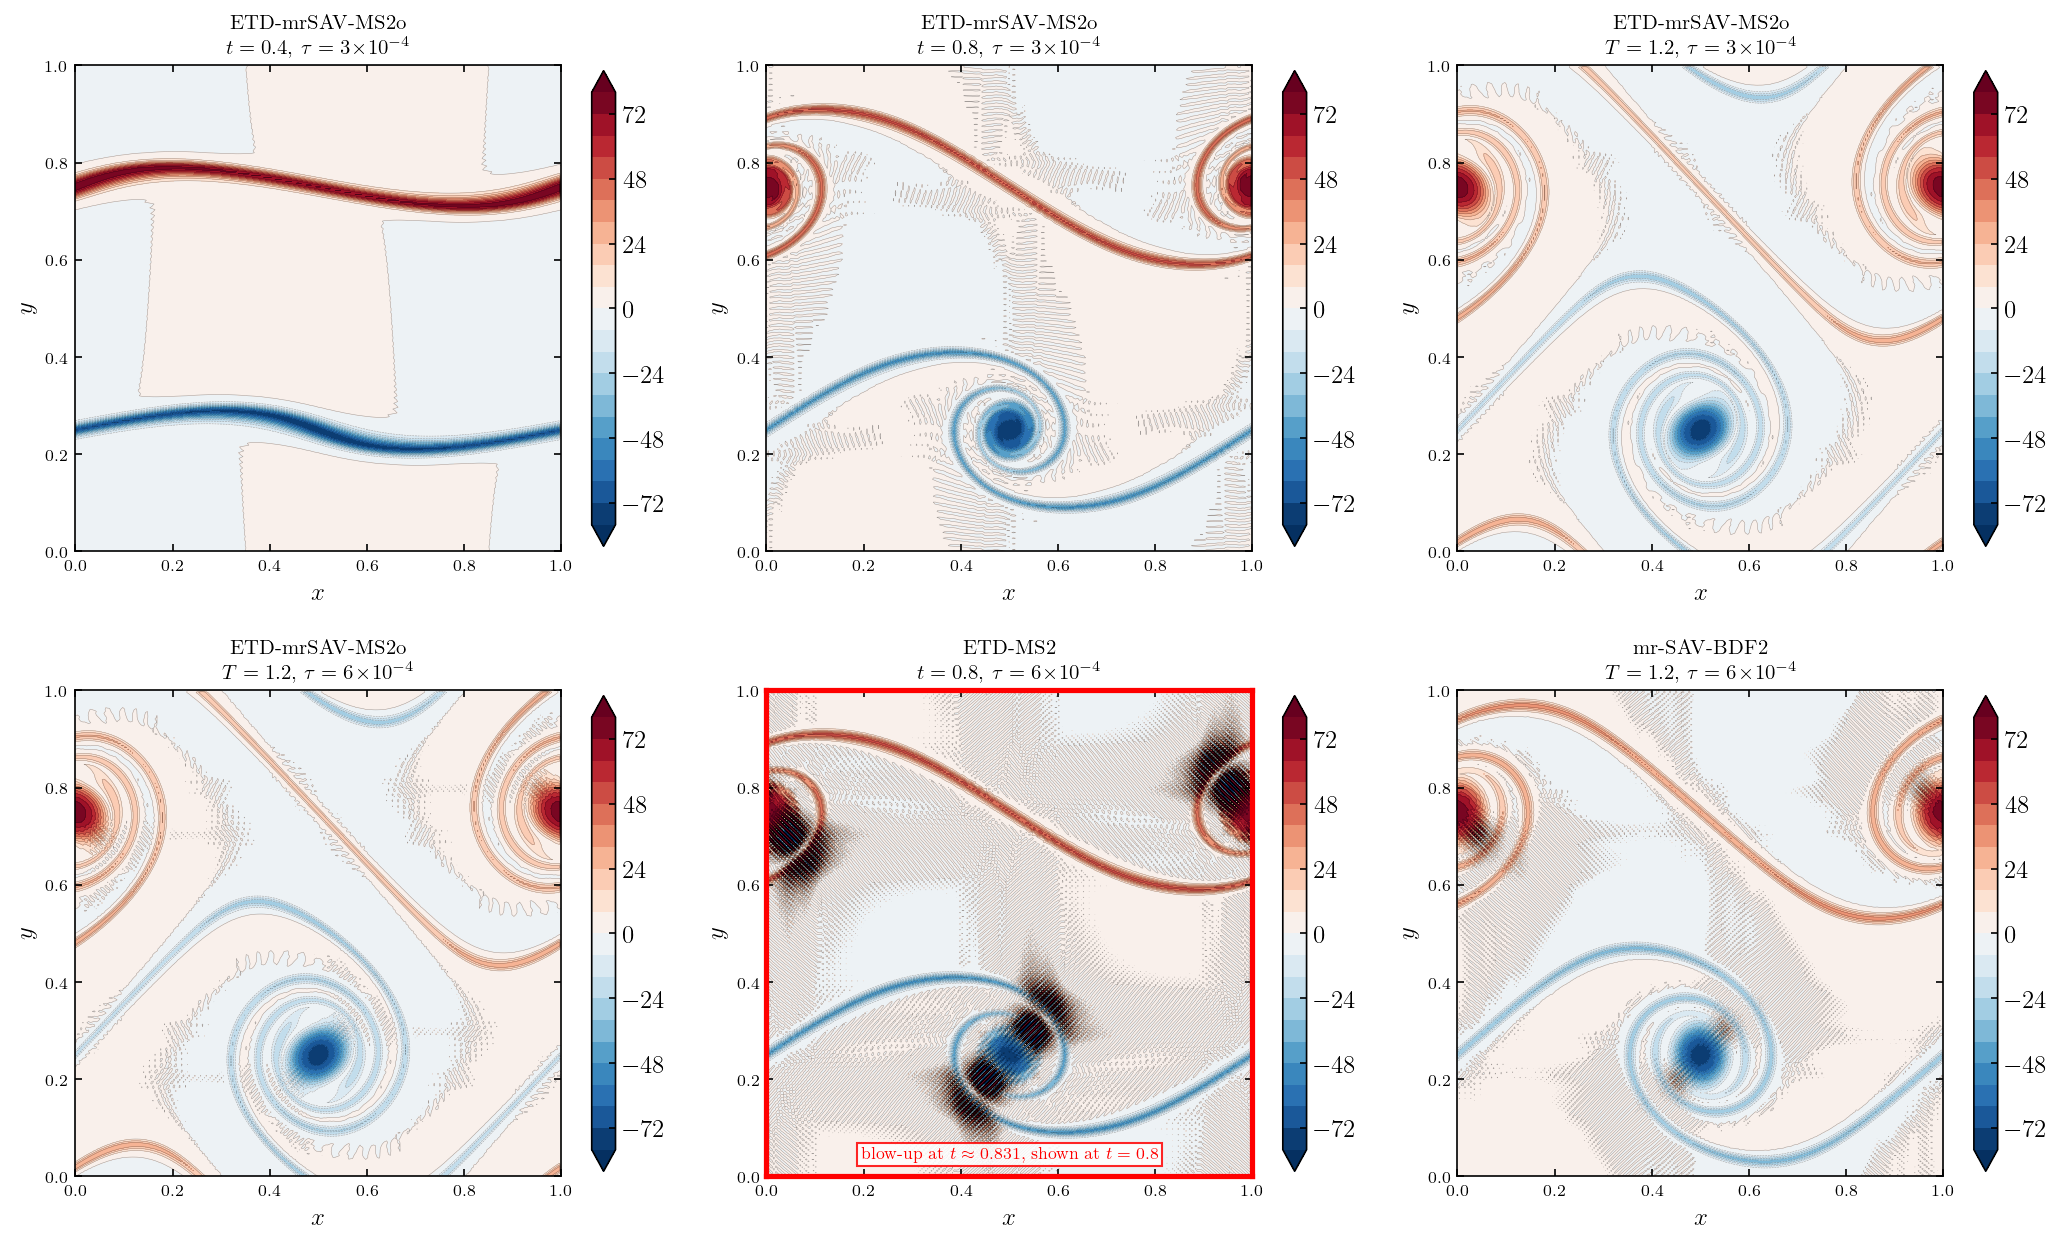

In [4]:

# ─── Figure 1: Vorticity comparison (2×3 grid) ──────────────────────────────
# Row 1 (reference): ETD-mrGSAV-MS2 with small δt = 3×10⁻⁴ at t = 0.4, 0.8, 1.2
# Row 2 (large δt):  ETD-mrGSAV-MS2 / ETD-MS2 / mr-SAV-BDF2 with δt = 6×10⁻⁴

def _omega_plot(omega, N):
    Xp, Yp = np.meshgrid(np.linspace(0, 1, N + 1), np.linspace(0, 1, N + 1))
    return Xp, Yp, np.pad(omega, ((0, 1), (0, 1)))

col_titles = [
    r'ETD-mrSAV-MS2o', r'ETD-mrSAV-MS2o', r'ETD-mrSAV-MS2o',
    r'ETD-mrSAV-MS2o', r'ETD-MS2',         r'mr-SAV-BDF2',
]
method_tag = [
    r'$t=0.4$, $\tau = 3\!\times\!10^{-4}$',
    r'$t=0.8$, $\tau = 3\!\times\!10^{-4}$',
    r'$T=1.2$, $\tau = 3\!\times\!10^{-4}$',
    r'$T=1.2$, $\tau = 6\!\times\!10^{-4}$',
    r'$t=0.8$, $\tau = 6\!\times\!10^{-4}$',
    r'$T=1.2$, $\tau = 6\!\times\!10^{-4}$',
]
row_labels = [
    r'Reference ($\tau = 3\!\times\!10^{-4}$)',
    r'Large $\tau = 6\!\times\!10^{-4}$',
]

omega_panels = [
    (omega_thin_T_ref[0],              N_thin),
    (omega_thin_T_ref[1],              N_thin),
    (omega_thin_T_ref[2],              N_thin),
    (omega_thin_T,                     N_thin),
    (omega_thin_pre_blowup_etdms2,     N_thin),
    (omega_thin_T_mrsav_bdf,           N_thin),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8.5), dpi=150)

for row in range(2):
    # row_omegas = [np.pad(omega_panels[row*3 + c][0], ((0,1),(0,1))) for c in range(3)]
    # vmax = max(np.nanmax(np.abs(o)) for o in row_omegas if np.any(np.isfinite(o)))
    vmax = 80

    for col in range(3):
        ax  = axes[row, col]
        idx = row * 3 + col
        omega, N = omega_panels[idx]
        Xp, Yp, op = _omega_plot(omega, N)

        if np.any(np.isfinite(op)):
            levels = np.linspace(-vmax, vmax, 21)
            cf = ax.contourf(Xp, Yp, op, levels=levels, cmap='RdBu_r', extend='both')
            ax.contour(Xp, Yp, op, levels=levels, colors='k', linewidths=0.25, alpha=0.35)
            plt.colorbar(cf, ax=ax, shrink=0.85)

        is_blowup_panel = (row == 1 and col == 1)
        if is_blowup_panel and t_blowup_thin is not None:
            for spine in ax.spines.values():
                spine.set_edgecolor('red'); spine.set_linewidth(2.5)
            ax.text(0.5, 0.03,
                    rf'blow-up at $t\approx{t_blowup_thin:.3f}$, shown at $t=0.8$',
                    ha='center', va='bottom', transform=ax.transAxes,
                    fontsize=8, color='red',
                    bbox=dict(fc='white', ec='red', lw=1, alpha=0.85, pad=2))

        ax.set_title(f'{col_titles[idx]}\n{method_tag[idx]}', fontsize=10)
        ax.set_xlabel(r'$x$')
        ax.set_ylabel(r'$y$')
        ax.set_aspect('equal')
        ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=8)

    # axes[row, 0].set_ylabel(row_labels[row] + '\n' + r'$y$', fontsize=9)

# fig.suptitle(r'Double shear layer — $\rho=100$, $\nu=5\!\times\!10^{-5}$, $256\!\times\!256$', y=1.01)
fig.tight_layout(pad=1., h_pad=1., w_pad=1.)
fig.savefig('fig/shear_layer_comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()


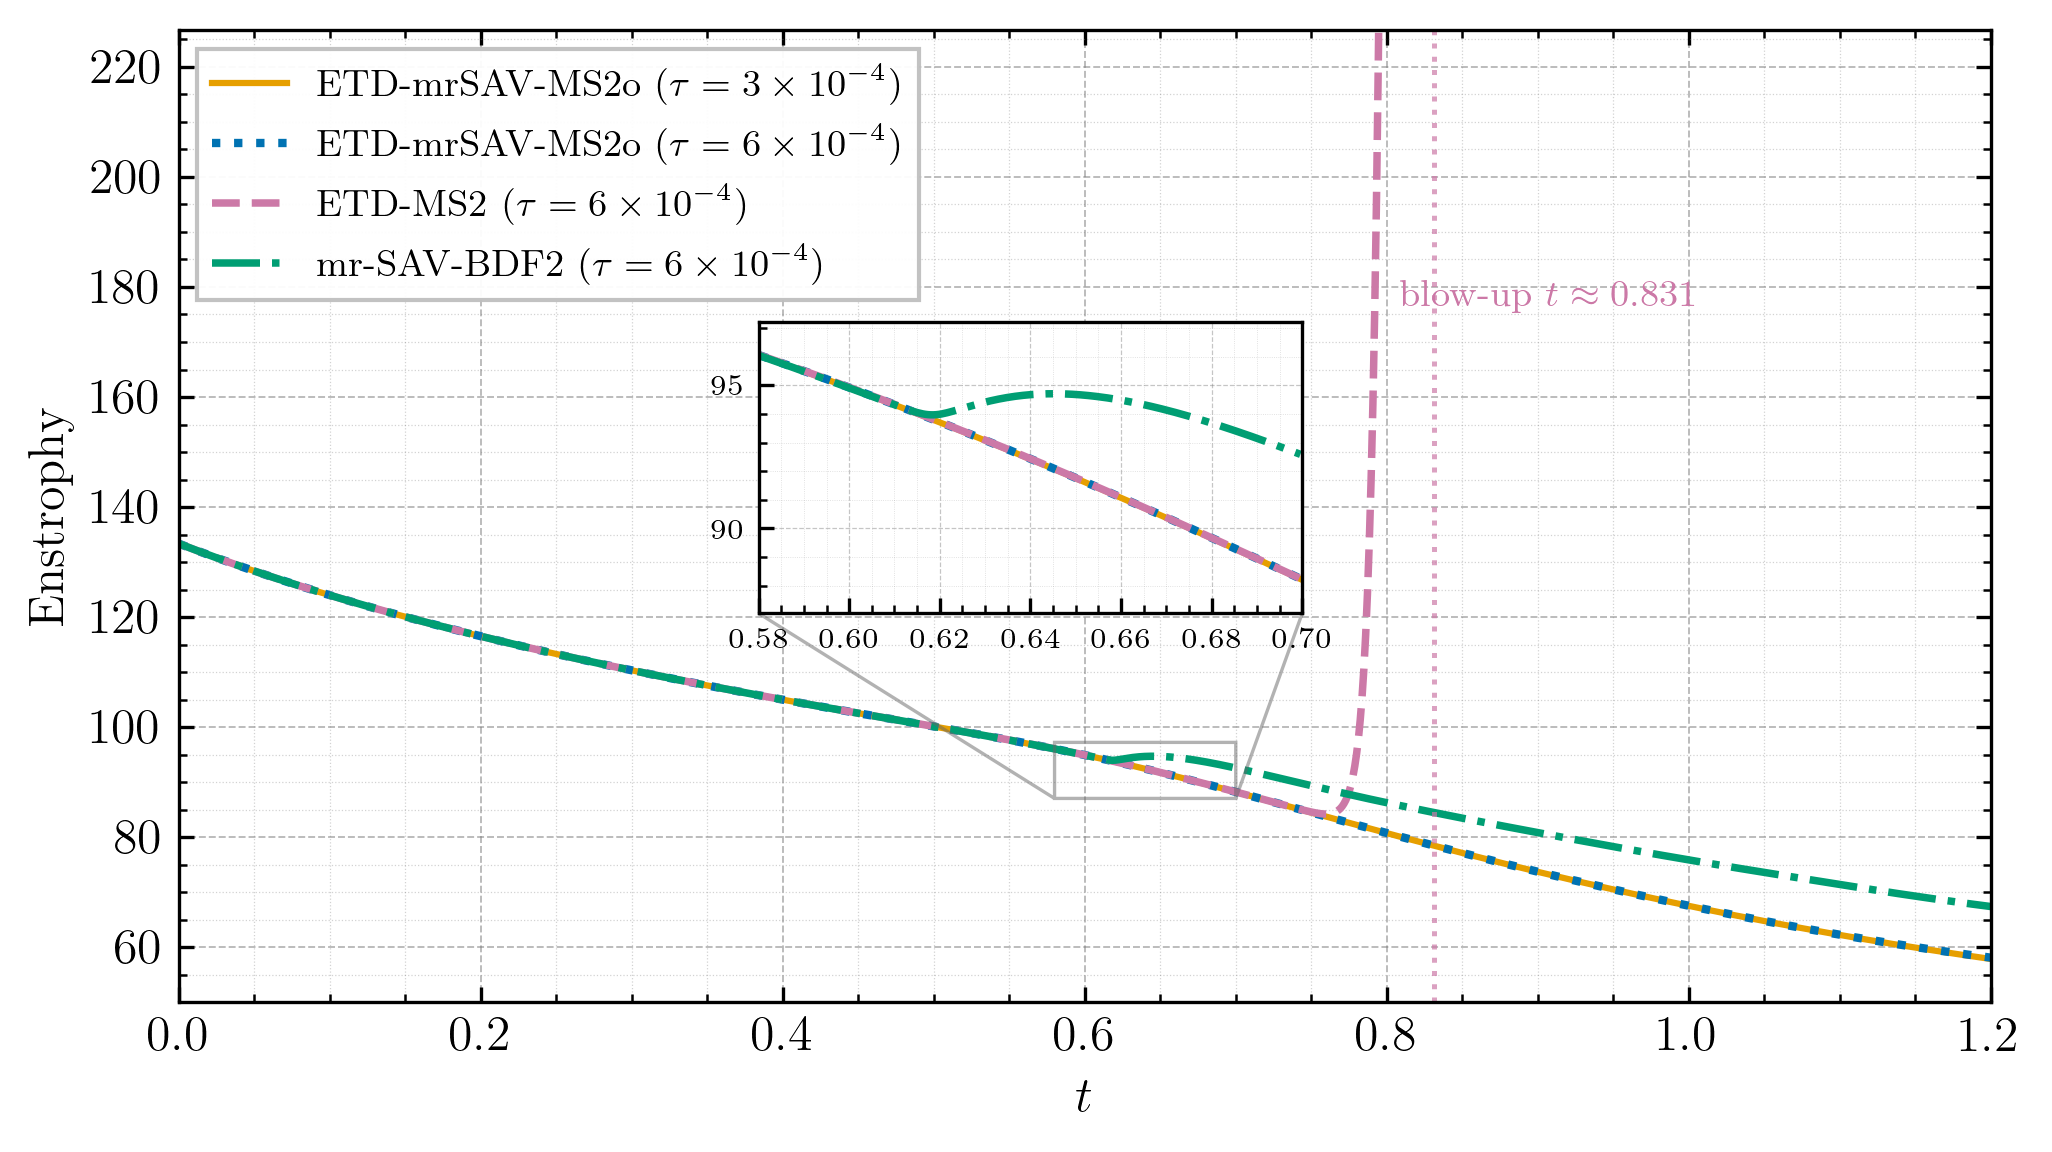

In [6]:

# ─── Figure 2: Enstrophy time history — thin layer stability ─────────────────
from matplotlib.ticker import LogLocator, AutoMinorLocator

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)

#                  solver              label                                              color      ls   lw   stable?
configs = [
    (solver_thin_ref,       r'ETD-mrSAV-MS2o ($\tau=3\times10^{-4}$)',  '#E69F00', '-',  1.5, True),
    (solver_thin,           r'ETD-mrSAV-MS2o ($\tau=6\times10^{-4}$)',  '#0072B2', ':',  2.0, True),
    (solver_thin_etdms2,    r'ETD-MS2 ($\tau=6\times10^{-4}$)',         '#CC79A7', '--', 1.8, False),
    (solver_thin_mrsav_bdf, r'mr-SAV-BDF2 ($\tau=6\times10^{-4}$)',     '#009E73', '-.', 1.8, True),
]

y_stable_max = 0.0
for solver, label, color, ls, lw, stable in configs:
    t   = solver.tn
    ens = solver.Enstrophy
    mask = np.isfinite(ens)
    ax.plot(t[mask], ens[mask], color=color, linestyle=ls, linewidth=lw, label=label)
    if stable:
        y_stable_max = max(y_stable_max, np.max(ens[mask]))

ax.set_xlim(0, T)
ax.set_ylim(50, y_stable_max * 1.7)

# Blow-up annotation
if t_blowup_thin is not None:
    ax.axvline(t_blowup_thin, color='#CC79A7', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.annotate(rf'blow-up $t\approx{t_blowup_thin:.3f}$',
                xy=(t_blowup_thin, ax.get_ylim()[1] * .8),
                xytext=(-8, 0), textcoords='offset points',
                color='#CC79A7', fontsize=9, va='top', ha='left')

ax.set_xlabel(r'$t$')
ax.set_ylabel(r'Enstrophy')
ax.legend(fontsize=9, loc='upper left',
          framealpha=0.95, edgecolor='0.75', fancybox=False)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(True, which='major', ls='--', lw=0.45, alpha=0.55, color='gray')
ax.grid(True, which='minor', ls=':',  lw=0.3,  alpha=0.35, color='gray')

# ─── Inset: zoom into t ∈ [0.58, 0.7] ───────────────────────────────────────
axins = ax.inset_axes([0.32, 0.4, 0.30, 0.30])

zoom_t0, zoom_t1 = 0.58, 0.7
for solver, label, color, ls, lw, stable in configs:
    t   = solver.tn
    ens = solver.Enstrophy
    mask = np.isfinite(ens) & (t >= zoom_t0) & (t <= zoom_t1)
    if mask.any():
        axins.plot(t[mask], ens[mask], color=color, linestyle=ls, linewidth=lw)

axins.set_xlim(zoom_t0, zoom_t1)
_vals = np.concatenate([
    s.Enstrophy[np.isfinite(s.Enstrophy) & (s.tn >= zoom_t0) & (s.tn <= zoom_t1)]
    for s, _, _, _, _, stable in configs if stable
])
if len(_vals):
    _lo, _hi = np.min(_vals), np.max(_vals)
    _pad = (_hi - _lo) * 0.15 or 0.5
    axins.set_ylim(_lo - _pad, _hi + _pad)

axins.tick_params(which='both', direction='in', labelsize=7)
axins.xaxis.set_minor_locator(AutoMinorLocator())
axins.yaxis.set_minor_locator(AutoMinorLocator())
axins.grid(True, which='major', ls='--', lw=0.3, alpha=0.45, color='gray')
axins.grid(True, which='minor', ls=':',  lw=0.2, alpha=0.3,  color='gray')


rect = ax.indicate_inset_zoom(axins, edgecolor='0.4', linewidth=0.8)
rect.connectors[0].set_visible(True)
rect.connectors[1].set_visible(False)
rect.connectors[2].set_visible(True)
rect.connectors[3].set_visible(False)

fig.tight_layout()
fig.savefig('fig/shear_layer_enstrophy.pdf', bbox_inches='tight', dpi=300)
plt.show()


\begin{exm}\label{exm:shear_layer}[Double shear layer]
In this example, we consider the double shear layer problem on $\Omega = (0,1)^2$ with viscosity $\nu = 5\times 10^{-5}$ and final time $T = 1.2$. The initial velocity field is prescribed as
\begin{equation*}
u_0(x,y) = \begin{cases} \tanh\!\bigl(\rho(y - \tfrac{1}{4})\bigr), & y \le \tfrac{1}{2}, \\[4pt] \tanh\!\bigl(\rho(\tfrac{3}{4} - y)\bigr), & y > \tfrac{1}{2}, \end{cases} \qquad v_0(x,y) = \delta \sin(2\pi x),
\end{equation*}
with $\rho = 100$ and $\delta = 0.05$, and the initial vorticity $\omega_0$ is obtained from the velocity field via spectral differentiation. No external forcing is applied ($f = 0$). The Reynolds number, $\mathrm{Re} := \|\bm{u}_0\|/\nu \approx 1.96\times 10^4$, is computed from the $L^2$ norm of the initial velocity $\|\bm{u}_0\| \approx 0.98$, placing the flow firmly in the convection-dominated regime. For spatial discretization, $256$ Fourier modes are used.
\end{exm}

We set the mean-reverting parameter $\gamma = 1000$ and $\tilde{\gamma} = 0.1$. Using a relatively large time step $\tau = 6\times 10^{-4}$, we compare three schemes: ETD-mr-SAV-MS2o, ETD-MS2, and mr-SAV-BDF2. The result produced by ETD-mr-SAV-MS2o with a finer time step $\tau = 3\times 10^{-4}$ serves as the reference solution. The vorticity contours at selected time instances are shown in Figure~\ref{fig:shear_vorticity}, and the enstrophy time histories are reported in Figure~\ref{fig:shear_enstrophy}.

From Figure~\ref{fig:shear_vorticity}, we observe that the double shear layer develops thin, rolling vortex structures as the flow evolves. The reference solution (top row) captures the progressive roll-up and thinning of the shear layers at $t = 0.4$, $0.8$, and $1.2$. Among the three schemes with the larger step size $\tau = 6\times 10^{-4}$ (bottom row), the ETD-mr-SAV-MS2o scheme produces vorticity fields in close agreement with the reference, demonstrating both stability and accuracy for this challenging problem. In contrast, the ETD-MS2 scheme suffers numerical blow-up at approximately $t \approx 0.831$; the panel at $t = 0.8$ captures the last valid state before divergence. The mr-SAV-BDF2 scheme remains stable throughout the simulation, but its vorticity contours exhibit noticeably greater numerical diffusion compared to the ETD-mr-SAV-MS2o result.

The enstrophy evolution in Figure~\ref{fig:shear_enstrophy} further confirms these observations. The ETD-mr-SAV-MS2o scheme with the larger time step tracks the reference enstrophy curve closely, while the ETD-MS2 enstrophy diverges rapidly near $t \approx 0.831$, indicating a loss of numerical stability. We note that in the absence of external forcing, the enstrophy of the Navier--Stokes equations is monotonically decreasing. The ETD-mr-SAV-MS2o scheme preserves this property at the discrete level. By contrast, although the mr-SAV-BDF2 scheme remains stable, it exhibits non-physical enstrophy growth, violating this fundamental dissipation property.

These results demonstrate the superior stability of the mean-reverting SAV formulation for flow problems involving thin vorticity layers. The ETD-mr-SAV-MS2o scheme permits larger time steps without inducing numerical blow-up or violating the fundamental dissipation properties.

\begin{figure}[htbp]
\centering
\includegraphics[width=\linewidth]{figure/shear_layer_comparison.pdf}
\caption{Vorticity contours for the double shear layer with $\rho = 100$, $\nu = 5\times 10^{-5}$. Top row: reference solution by ETD-mr-SAV-MS2o with $\tau = 3\times 10^{-4}$ at $t = 0.4$, $0.8$, and $1.2$. Bottom row: ETD-mr-SAV-MS2o, ETD-MS2, and mr-SAV-BDF2 with $\tau = 6\times 10^{-4}$. The ETD-MS2 panel (red border) shows the last valid state at $t = 0.8$ before blow-up at $t \approx 0.831$.}
\label{fig:shear_vorticity}
\end{figure}

\begin{figure}[htbp]
\centering
\includegraphics[width=0.85\linewidth]{figure/shear_layer_enstrophy.pdf}
\caption{Time evolution of enstrophy for the double shear layer problem. The ETD-MS2 scheme diverges at $t \approx 0.831$, while ETD-mr-SAV-MS2o remains stable and closely tracks the reference even at the larger time step $\tau = 6\times 10^{-4}$. The mr-SAV-BDF2 scheme exhibits non-physical enstrophy growth, violating the monotonic decrease guaranteed by the continuous equations in the absence of external forcing.}
\label{fig:shear_enstrophy}
\end{figure}